# RAG FOR PROJECT


Loding API KEYS IN .env

In [ ]:
'''# no needed now , coz i use ollama locally instead of openai api
from dotenv import load_dotenv
import os

load_dotenv()

print("API key loaded:", bool(os.getenv("OPENAI_API_KEY")))''''''

API key loaded: True


## Documents Loader 

### 1. TextLoader

In [2]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader("sample-folder/content.txt", encoding="utf-8")

docs = loader.load()
print(type(docs))  # type og docs is list
print(len(docs))   # number of documents in this list
print(type(docs[0]))  # type of the first document in the list

print(docs[0].page_content)  # print the content of the first document

print(docs[0].metadata)  # print the metadata of the first document # {'source': 'content.txt'}


<class 'list'>
1
<class 'langchain_core.documents.base.Document'>
**The Light We Carry**

At dawn, the city lifts its eyes,  
And gathers gold from quiet skies.  
The rooftops shine, the windows gleam,  
The waking world steps from a dream.  

A sparrow stitches songs through air,  
While footsteps bloom along the square.  
The river, wrapped in silver thread,  
Carries the stars where night has fled.  

I walk beneath the tender blue,  
With yesterday still clinging through  
The pockets of my worn-out coat—  
A half-remembered word, a note,  
A photograph, a vanished face,  
A little sorrow time can’t erase.  

Yet morning does not ask me why  
I bring old shadows to the sky.  
It simply opens, wide and bright,  
A thousand doors of patient light.  

So I release the weight I bear,  
And breathe the freshness everywhere.  
The trees applaud with emerald leaves,  
The wind untangles all it grieves.  

Perhaps the heart is made to mend  
In quiet ways we comprehend:  
A hand held out, 

In [62]:
from langchain_community.document_loaders import TextLoader
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
#from dotenv import load_dotenv

#load_dotenv()

model = ChatOllama(
    model="llama3.2",
    temprature=0.7
)

prompt = PromptTemplate(
    template = " write a summery for the following poem: - \n {poem}",
    imput_variables = ["poem"]
)
perser = StrOutputParser()

chain = prompt | model | perser

print(chain.invoke({"poem": docs[0].page_content}))

Here's a summary of the poem "The Light We Carry":

The poem "The Light We Carry" is a contemplative and hopeful reflection on the human experience. It describes the dawn of a new day and the city's awakening, using vivid imagery to convey the beauty and light of the world. The speaker reflects on the weight of their own personal burdens, including grief, sorrow, and past hurts, which they carry with them. However, instead of allowing these emotions to consume them, they release the weight and breathe in the fresh light of the day. The poem suggests that even in darkness, the smallest spark of hope and resilience can be a powerful force, and that with time, healing, and support, we can learn to mend and rise above our struggles. Ultimately, the poem offers a message of hope and renewal, suggesting that the light we carry within ourselves can guide us through even the most challenging times.


### 2. PyPDFLoader
works mainly for text pdf data not work for scanned page pdf data 


More pdf loader:
1. Simple PDFs loader --- PyPDFLoader
2. PDFs with table, columns --- PDFPlumberLoader
3. Scanned/ image PDF --- UnstructuredPDFLoader or AmazonTextractPDFLoader (for OCR )
4. Need layout and image data --- PyPDFLoader
5. Want best structure extraction --- UnstructuredPDFLoader

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("12530823008-sample.pdf")

docs = loader.load()
print(len(docs))

print(docs[0].page_content)  # print the content of the first document
print(docs[4].metadata)  # print the metadata of the first document # {'source': 'content.txt'}

14
{'producer': 'Microsoft® Word 2021', 'creator': 'Microsoft® Word 2021', 'creationdate': '2026-09-12T14:53:33+05:30', 'author': 'Chandan kumar', 'moddate': '2026-09-12T14:53:33+05:30', 'source': '12530823008-sample.pdf', 'total_pages': 14, 'page': 4, 'page_label': '5'}


In [33]:
from langchain_community.document_loaders import UnstructuredPDFLoader

loader = UnstructuredPDFLoader("DSA_CompleteNotes.pdf")
docs = loader.load()
print(len(docs))

#print(docs[0].page_content)  # print the content of the first document
print(docs[0].metadata)  # print the metadata of the first document # {'source': 'content.txt'}

No languages specified, defaulting to English.


1
{'source': 'DSA_CompleteNotes.pdf'}


### 3. Directory Loader
load all documents from a entire folder

In [39]:
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader

loader = DirectoryLoader(
    path = "sample-folder",
    glob = "*.pdf",
    loader_cls = PyPDFLoader
)

docs = loader.load()
print(len(docs))
print(docs[0].page_content)  # print the content of the first document
print(docs[0].metadata)  # print the metadata of the first document

39
BENGAL COLLEGE OF ENGINEERING AND 
TECHNOLOGY
DURGAPUR WEST BENGAL
NAME:
-
                  
 CHANDAN 
KUMAR
BRANCH:
-
              
 CSE
(AI&ML)
ROLL NO.:
-
            
 08
SUBJECT:
-
               
OPTIMIZATION TECHNIQUES
UNIV. ROLL NO.:
-
  
12530823008
SUBJECT CODE :
-
   
PCCAIML 402
FACULTY :
-
             
 RAKHI 
DAS
PRESENTED BY:-
{'producer': 'iLovePDF', 'creator': 'Microsoft® PowerPoint® 2021', 'creationdate': '2025-02-21T22:46:04+05:30', 'author': 'Chandan kumar', 'moddate': '2025-02-27T07:49:09+00:00', 'source': 'sample-folder\\12530823008-CHANDAN.KR-OT.pdf', 'total_pages': 16, 'page': 0, 'page_label': '1'}


**Load and Lazy load**:
* --Load: Eager loading (load everything at once in memory).
* --Return a list of (documents) Objects.
* --Best -- No. of Doc is small, want everything loaded upfront

* -- Lazy Load: Lazy Loading(loads on demands not all were loaded at once).
* --Return a generator of (documents) objects.
8 --Best -- Dealing with large no. of docs, useful for stream preprocessing(embeddin, chunking) without using lots of memory

In [44]:
'''docs = loader.load()  # this load all the odf in memory at once, which is not good for large number of files. So we can use lazy loading instead.

for document in docs:
    print(document.metadata)'''

docs = loader.lazy_load()  # this will return a generator object, which will load the documents one by one(one will load in memory then removed then again same with second one), which is good for large number of files.
for document in docs:
    print(document.metadata)

{'producer': 'iLovePDF', 'creator': 'Microsoft® PowerPoint® 2021', 'creationdate': '2025-02-21T22:46:04+05:30', 'author': 'Chandan kumar', 'moddate': '2025-02-27T07:49:09+00:00', 'source': 'sample-folder\\12530823008-CHANDAN.KR-OT.pdf', 'total_pages': 16, 'page': 0, 'page_label': '1'}
{'producer': 'iLovePDF', 'creator': 'Microsoft® PowerPoint® 2021', 'creationdate': '2025-02-21T22:46:04+05:30', 'author': 'Chandan kumar', 'moddate': '2025-02-27T07:49:09+00:00', 'source': 'sample-folder\\12530823008-CHANDAN.KR-OT.pdf', 'total_pages': 16, 'page': 1, 'page_label': '2'}
{'producer': 'iLovePDF', 'creator': 'Microsoft® PowerPoint® 2021', 'creationdate': '2025-02-21T22:46:04+05:30', 'author': 'Chandan kumar', 'moddate': '2025-02-27T07:49:09+00:00', 'source': 'sample-folder\\12530823008-CHANDAN.KR-OT.pdf', 'total_pages': 16, 'page': 2, 'page_label': '3'}
{'producer': 'iLovePDF', 'creator': 'Microsoft® PowerPoint® 2021', 'creationdate': '2025-02-21T22:46:04+05:30', 'author': 'Chandan kumar', 'mo

### 4. WebBase Loader
Used to load and extract text content from web pages(URLs).
Best: - for blogs, news articles, or public websites where the content is primarily text based and static
Limit: - Doesn't handle javascript heavy pages well (use SeleniumURLLoader for that).

In [ ]:
from langchain_community.document_loaders import WebBaseLoader

url = "https://research.google/blog/transformer-a-novel-neural-network-architecture-for-language-understanding/"
loader = WebBaseLoader(url)

web_docs = loader.load()
print(len(web_docs))

print(web_docs[0].page_content)  # print the content of the first document

1






Transformer: A Novel Neural Network Architecture for Language Understanding






















Skip to main content













Explore our many areas of focus





        
          Explore all research areas
        
      









Applied AI & sciences











Earth AI












Health AI












Science AI












Sustainability & crisis resilience









Foundational ML & algorithms











Algorithms & theory












Information retrieval












Machine intelligence












Machine perception












Natural language processing









People, systems & quantum AI











Human-computer interaction and visualization












Networking












Quantum AI












Responsible AI












Anti abuse












Software engineering












Software systems









Learn More











Publications












Projects














Building a collaborative ecosystem
















Datasets
Access high-quality 

In [63]:
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

model = ChatOllama(
    model="llama3.2",
    temprature=0.7
)
prompt = PromptTemplate(
    template = " Answrer the folloeing questions \n {question} from the following text: - \n {text}",
    input_variables = ["question", "text"]
)
perser = StrOutputParser()

url = "https://research.google/blog/transformer-a-novel-neural-network-architecture-for-language-understanding/"
loader = WebBaseLoader(url)

docs = loader.load()

chain = prompt | model | perser
print(chain.invoke({"question": "What is the transformer architecture?", "text": docs[0].page_content}))



The Transformer is a novel neural network architecture introduced in the paper "Attention Is All You Need" by Jakob Uszkoreit, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Łukasz Kaiser, and Illia Polosukhin. It is designed for language understanding tasks such as language modeling, machine translation, and question answering.

The Transformer architecture is based on a self-attention mechanism that directly models relationships between all words in a sentence, regardless of their respective position. This is in contrast to traditional recurrent neural networks (RNNs) and convolutional neural networks (CNNs), which are more sequential and require multiple steps to combine information from distant parts of the input.

The Transformer works by comparing each word to every other word in the sentence, computing an attention score for each other word, and using these scores to determine how much each word should contribute to the next representation of a given wo

### 5. CSV Loader
create a particular document object for each row

In [70]:
from langchain_community.document_loaders import CSVLoader

loader = CSVLoader(file_path="exercise.csv", encoding="utf-8")

docs = loader.load()
print(len(docs))
print(docs[0].page_content)  # print the content of the first document
print(docs[0].metadata)  # print the metadata of the first document # {'source': 'content.txt'}

print(docs[5])

15000
User_ID: 14733363
Gender: male
Age: 68
Height: 190.0
Weight: 94.0
Duration: 29.0
Heart_Rate: 105.0
Body_Temp: 40.8
{'source': 'exercise.csv', 'row': 0}
page_content='User_ID: 15130815
Gender: female
Age: 36
Height: 151.0
Weight: 50.0
Duration: 23.0
Heart_Rate: 96.0
Body_Temp: 40.7' metadata={'source': 'exercise.csv', 'row': 5}


In [76]:
docs = loader.lazy_load()
for document in docs:
    print(document.page_content)

User_ID: 14733363
Gender: male
Age: 68
Height: 190.0
Weight: 94.0
Duration: 29.0
Heart_Rate: 105.0
Body_Temp: 40.8
User_ID: 14861698
Gender: female
Age: 20
Height: 166.0
Weight: 60.0
Duration: 14.0
Heart_Rate: 94.0
Body_Temp: 40.3
User_ID: 11179863
Gender: male
Age: 69
Height: 179.0
Weight: 79.0
Duration: 5.0
Heart_Rate: 88.0
Body_Temp: 38.7
User_ID: 16180408
Gender: female
Age: 34
Height: 179.0
Weight: 71.0
Duration: 13.0
Heart_Rate: 100.0
Body_Temp: 40.5
User_ID: 17771927
Gender: female
Age: 27
Height: 154.0
Weight: 58.0
Duration: 10.0
Heart_Rate: 81.0
Body_Temp: 39.8
User_ID: 15130815
Gender: female
Age: 36
Height: 151.0
Weight: 50.0
Duration: 23.0
Heart_Rate: 96.0
Body_Temp: 40.7
User_ID: 19602372
Gender: female
Age: 33
Height: 158.0
Weight: 56.0
Duration: 22.0
Heart_Rate: 95.0
Body_Temp: 40.5
User_ID: 11117088
Gender: male
Age: 41
Height: 175.0
Weight: 85.0
Duration: 25.0
Heart_Rate: 100.0
Body_Temp: 40.7
User_ID: 12132339
Gender: male
Age: 60
Height: 186.0
Weight: 94.0
Duration: 

## Text Splitters
Tasks : Embedding, Semantic Search, Summarization

Text splitting is the process of breaking large chunks of text (like articles, PDFs, HTML pages, or biiks) into smaller, managable pieces (chunks) that an LLM can handle effectively. 
-- Working with smaller chunks of text can be more memory-efficirnt and allow for better parallelization of processing tasks.
TASK:
* Why Embedding: -- Short chunks yield more accurate vectors.
* Why Semantic Search: -- Search results point to focused info. not noise.
* Why Summarization: -- Prrevent Hallucination and topic drift.

METHODS: 
* -- Length Based
* -- Text Structure Based
* -- Document Structure Based
* -- Semantic Meaning Based


### 1. Length Based Text Splitter :


In [ ]:
from langchain_text_splitters import CharacterTextSplitter

text = """A sparrow stitches songs through air, While footsteps bloom along the square. 
The river, wrapped in silver thread, Carries the stars where night has fled. 
I walk beneath the tender blue, With yesterday still clinging through The pockets of my worn-out coat- A half-remembered word, a note, A photograph, a vanished face, A little sorrow time can't erase.
Yet morning does not ask me why I bring old shadows to the sky. It simply opens, wide and bright, A thousand doors of patient light. So I release the weight I bear, And breathe the freshness everywhere.  
The trees applaud with emerald leaves,  
The wind untangles all it grieves. Perhaps the heart is made to mend In quiet ways we comprehend: A hand held out, 
a song begun, A road that turns toward rising sun."""

splitter = CharacterTextSplitter(
    chunk_size = 100,
    chunk_overlap = 0,
    separator = ''
)
result = splitter.split_text(text)
print(len(result))
print(result)

8
['A sparrow stitches songs through air, While footsteps bloom along the square. \nThe river, wrapped in', 'silver thread, Carries the stars where night has fled. \nI walk beneath the tender blue, With yester', 'day still clinging through The pockets of my worn-out coat- A half-remembered word, a note, A photog', "raph, a vanished face, A little sorrow time can't erase.\nYet morning does not ask me why I bring old", 'shadows to the sky. It simply opens, wide and bright, A thousand doors of patient light. So I relea', 'se the weight I bear, And breathe the freshness everywhere.  \nThe trees applaud with emerald leaves,', 'The wind untangles all it grieves. Perhaps the heart is made to mend In quiet ways we comprehend:', 'A hand held out, a song begun, A road that turns toward rising sun.']


splitting documents

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import CharacterTextSplitter

loader = PyPDFLoader("sample-folder/Environment Watercolor Marketing Plan XL by Slidesgo.pdf")

docs = loader.load()

splitter = CharacterTextSplitter(
    chunk_size = 100, # size of each chunk
    separator = '', # separator to use when splitting the text
    chunk_overlap = 10 # both chunks got some similar context
)

result = splitter.split_documents(docs)

#print(result[0]) # print the first chunk of the first document
print(result[0].page_content) # print the metadata of the first chunk of the first document
print(len(result[0].page_content))


BENGAL COLLEGE 
OF ENGINEERING & 
TECHNOLOGY
NAME- BISHAL ROY    
BRANCH- CSE(AI&ML)
ROLL NO.- 07
SU
100


### 2. Text-Structured Based
Break the text based on words and Merge after that should not increase more than chunk size 

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text = """A sparrow stitches songs through air, While footsteps bloom along the square. 
The river, wrapped in silver thread, Carries the stars where night has fled. 
I walk beneath the tender blue, With yesterday still clinging through The pockets of my worn-out coat- A half-remembered word, a note, A photograph, a vanished face, A little sorrow time can't erase.
Yet morning does not ask me why I bring old shadows to the sky. It simply opens, wide and bright, A thousand doors of patient light. So I release the weight I bear, And breathe the freshness everywhere.  
The trees applaud with emerald leaves,  
The wind untangles all it grieves. Perhaps the heart is made to mend In quiet ways we comprehend: A hand held out, 
a song begun, A road that turns toward rising sun."""

splitter = RecursiveCharacterTextSplitter(
    chunk_size = 70,
    chunk_overlap = 0,
)
# performing the split
result  = splitter.split_text(text)
print(len(result))  # number of chunks created
print(result[0])  # print the first chunk
print(len(result[0]))  # length of the first chunk

14
A sparrow stitches songs through air, While footsteps bloom along the
69


splitting chunks from documents

In [70]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("sample-folder/Environment Watercolor Marketing Plan XL by Slidesgo.pdf")

docs = loader.load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500, # size of each chunk
    chunk_overlap = 10, # both chunks got some similar context
)

result = splitter.split_documents(docs)
print(len(result))  # number of chunks created 
print(result[7].page_content)  # print the first chunk of the first document
print(len(result[7].page_content))  # length of the first chunk of the first document

12
CONCLUSION
•The layered structure of the Earth's atmosphere plays a 
crucial role in maintaining life and regulating the planet's 
climate. 
•Understanding the characteristics of each layer is 
essential for studying atmospheric phenomena and 
addressing environmental challenges.
•Human activities are impacting the atmosphere's 
composition and structure, leading to climate change and 
other environmental problems.
418


### 3. Document-Structured Based (code)


In [81]:
from langchain_text_splitters import RecursiveCharacterTextSplitter,Language

text = """
class Student:
    def __init__(self, name, age, grade):
        self.name = name
        self.age = age
        self.grade = grade # grade is a float(like 8.6, 9.0)
    
    def get_details(self):
        return self.name, self.age, self.grade

#Example usage
student1 = Student("John", 15, 9.0)
print(student1.get_details())  # Output: ('John', 15, 9.0)

if student1.is_passing():
    print("student is passing.")
else:
    print("student is not passing.")
"""
# initializiing the splitter
splitter = RecursiveCharacterTextSplitter.from_language(
    chunk_size = 200,
    chunk_overlap = 0,
    language = Language.PYTHON
)
chunks = splitter.split_text(text)

print(chunks)  # print the entire chunks created
print(len(chunks))  # print the number of chunks created
print(chunks[1]) 
print(len(chunks[1]))  # print the length of the second chunk

['class Student:\n    def __init__(self, name, age, grade):\n        self.name = name\n        self.age = age\n        self.grade = grade # grade is a float(like 8.6, 9.0)', 'def get_details(self):\n        return self.name, self.age, self.grade\n\n#Example usage\nstudent1 = Student("John", 15, 9.0)\nprint(student1.get_details())  # Output: (\'John\', 15, 9.0)', 'if student1.is_passing():\n    print("student is passing.")\nelse:\n    print("student is not passing.")']
3
def get_details(self):
        return self.name, self.age, self.grade

#Example usage
student1 = Student("John", 15, 9.0)
print(student1.get_details())  # Output: ('John', 15, 9.0)
180


### 4. Semantic Meaning Based
Related semantic has similar vector , Use sliding windows concept

In [37]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_ollama.embeddings import OllamaEmbeddings

# loading embedding model from local ollama
embeddings = OllamaEmbeddings(model = "nomic-embed-text")

text_splitter = SemanticChunker(
    embeddings,
    breakpoint_threshold_type = "standard_deviation", 
    # if distances b/w two sentences is more than 1 or less than 1 (based on breakingpoint_threshold_type and given amount)-- then it the braking point (we split text)
    breakpoint_threshold_amount = 1
)
text = """
Artificial Intelligence is a branch of computer science.
Machine learning is a subset of artificial intelligence.
Deep learning uses neural networks to learn patterns.
IPL means Indian Premier League.
Chandan is a B.Tech student.
Python is a programming language.
Python is widely used for data science.
Python is also used for machine learning."""

docs = text_splitter.create_documents([text])
print(len(docs))
print(docs)
print(chunk)

3
[Document(metadata={}, page_content='\nArtificial Intelligence is a branch of computer science. Machine learning is a subset of artificial intelligence.'), Document(metadata={}, page_content='Deep learning uses neural networks to learn patterns. IPL means Indian Premier League. Chandan is a B.Tech student. Python is a programming language.'), Document(metadata={}, page_content='Python is widely used for data science. Python is also used for machine learning.')]
Python is widely used for data science. Python is also used for machine learning. 


## Vector Stores

It is a system designed to store and retrieve data represented as numerical vectors.
- Features:
1. -- Storage - Ensures that vectors and their associated metadata are retained whether in-memory for quick lookups or On-disk for durability.
2. -- Similarity Search - Helps retrieve the vectors most similar to a query vector
3. -- Indexing - Provide a data structure or method that enables fast similarity searches on high-dimensional vectors (e.g - approximate nearsest lookups)
4. -- CRUD Operations - Manage the lifecycle of data - adding new vectors, reading them, updating existing entities, removing outdated vectors.

* Use-cases:
- RAG,   - Semantic Search,   - Recommender Systems,   - Image/Multimedia Search

In [ ]:
# pip install termcolor
from termcolor import colored

print(colored("Pratyush is Banrakas of Patna city and Budha is Insani-Bedhiya", 'green',attrs= ['bold', 'dark', 'underline']))#, 'blink', 'reverse', 'concealed']))
print(colored("Chandan is very good boy", 'red', 'on_cyan'))

Pratyush is Banrakas of Patna city and Budha is Insani-Bedhiya
Chandan is very good boy


### Vector Store and Vector DataBase:

* 1. Vector Store
A vector store is a system specifically designed to hold and retrieve vector embeddings.
It focuses primarily on storing and retrieving these embeddings efficiently.
Ideal for lightweight applications, such as retrieval-augmented generation (RAG) or semantic search.

-- Purpose: Store and retrieve vector embeddings

EX:- (FAISS, pinecore, Chroma, Qdrant, Weaviate, etc.)
* 2. Vector Database
A vector database is a more comprehensive solution that manages, indexes, and queries vector embeddings at scale.
It includes features like data persistence(Backup/Restore), advanced querying capabilities, and metadata filtering(schemas, filters).
Designed for enterprise-grade applications, it can handle massive datasets and complex queries.
Offers additional "Database-like" features:
* Distributed architecture for hoorizontal scaling
* Potential for ACID or near-ACID gurantees 
* Authentication/ Authorization and more advanced security
* (A → Atomicity, C → Consistency, I → Isolation, D → Durability):
* A -- Atomicity means a transaction is treated as one indivisible unit: either all its operations are completed, or none are.
* C -- Consistency ensures that a transaction takes the database from one valid state to another valid state while preserving all defined rules and constraints.
* I -- Isolation ensures that concurrent transactions do not interfere with each other in a way that produces incorrect results.
* D -- Durability ensures that once a transaction has been successfully committed, its changes persist even if a system failure occurs afterward.

-- Purpose: Manage, index, and query embeddings


Chroma Vector Store Hierarchy:

                            Tenant (User)
                                |
                DataBase               DataBase
                    |                      |
        {Collection   Collection}  {Collection  Collection}
             |             |             |            |
        {Doc} {Doc}       {Doc} {Doc}    {Doc} {Doc}     {Doc} {Doc}

In [ ]:
from langchain_chroma import Chroma # chroma Vector Store
from langchain_ollama import OllamaEmbeddings # embedding model

from langchain_core.documents import Document # to create documents

# creating some docs 
doc1 = Document(
    page_content = "A sparrow stitches songs through air, While footsteps bloom along the square. The river, wrapped in silver thread, Carries the stars where night has fled.",
    metadata = {"poem": "line2"}
)
doc2 = Document(
    page_content = "I walk beneath the tender blue, With yesterday still clinging through The pockets of my worn-out coat— A half-remembered word, a note, A photograph, a vanished face,A little sorrow time cannot erase.",
    metadata = {"poem": "line3"}
)
doc3 = Document(
    page_content= "Yet morning does not ask me why I bring old shadows to the sky. It simply opens, wide and bright, A thousand doors of patient light.",
    metadata = {"poem": "line4"}
)

docs = [doc1, doc2, doc3]

# creating a chroma vector store
vector_store = Chroma(
    embedding_function=OllamaEmbeddings(model= "nomic-embed-text"),# model name 
    persist_directory = "chroma_db", # directory name
    collection_name="sample1" # name of collection where our docs stored
)
# create a chroma.sqlite3 

SyntaxError: invalid syntax (3862774469.py, line 21)

In [46]:
# adding new doc
doc4 =Document(
    page_content="So I release the weight I bear, And breathe the freshness everywhere. The trees applaud with emerald leaves, The wind untangles all it grieves. ",
    metadata = {"poem": "line5"}
)
docs2 = [doc4]
vector_store.add_documents(docs2)

['704a76dd-db4f-4e00-a3ad-882d084438d0']

In [47]:
# adding docs in chroma_db
vector_store.add_documents(docs)

# add_documents can add multiples of docs and each doc assigned with a unique id 


['ef5c3e5d-6c5f-491f-a8d1-63a22d06bd48',
 'a1a65f30-0655-47a0-a67a-f280701dc9ae',
 '96a2a2ad-666b-4e0a-96ca-cf747f184da0']

In [48]:
# viwe documents
vector_store.get(include=['embeddings', 'documents', 'metadatas'])

{'ids': ['0af0cb61-d031-4035-abea-108e9b1be90a',
  '866ccbd6-c476-4e52-81e2-c81e447024cc',
  'b1bcd683-c3e5-43dc-901d-57f3121a53bf',
  'cce77cdd-b65c-48bb-aa33-f4724242d51d',
  '7e2da0fd-214b-4f9a-8559-099be1598047',
  '704a76dd-db4f-4e00-a3ad-882d084438d0',
  'ef5c3e5d-6c5f-491f-a8d1-63a22d06bd48',
  'a1a65f30-0655-47a0-a67a-f280701dc9ae',
  '96a2a2ad-666b-4e0a-96ca-cf747f184da0'],
 'embeddings': array([[ 0.05653694, -0.0207997 , -0.1573787 , ..., -0.00545812,
          0.01242508, -0.03498092],
        [-0.02743766,  0.03938766, -0.16750042, ..., -0.0160546 ,
         -0.03402146,  0.01264977],
        [ 0.01544145, -0.00049168, -0.19677585, ..., -0.04941445,
         -0.0242306 , -0.00070279],
        ...,
        [ 0.01544145, -0.00049168, -0.19677585, ..., -0.04941445,
         -0.0242306 , -0.00070279],
        [ 0.05653694, -0.0207997 , -0.1573787 , ..., -0.00545812,
          0.01242508, -0.03498092],
        [-0.02743766,  0.03938766, -0.16750042, ..., -0.0160546 ,
         -0

In [ ]:
# searching in vector store

vector_store.similarity_search(
    query= 'what is worn-out?',
    k=1 # no. of similar rcluster user want
)


[Document(id='0af0cb61-d031-4035-abea-108e9b1be90a', metadata={'poem': 'line3'}, page_content='I walk beneath the tender blue, With yesterday still clinging through The pockets of my worn-out coat— A half-remembered word, a note, A photograph, a vanished face,A little sorrow time cannot erase.')]

In [ ]:
# search by similarity score

vector_store.similarity_search_with_score(
    query='what is a half-remembered word?',
    k=3
)
# then less score the best result

[(Document(id='0af0cb61-d031-4035-abea-108e9b1be90a', metadata={'poem': 'line3'}, page_content='I walk beneath the tender blue, With yesterday still clinging through The pockets of my worn-out coat— A half-remembered word, a note, A photograph, a vanished face,A little sorrow time cannot erase.'),
  0.8135656118392944),
 (Document(id='41570443-00f7-4090-bfa0-bfdcc55d8982', metadata={'poem': 'line2'}, page_content='A sparrow stitches songs through air, While footsteps bloom along the square. The river, wrapped in silver thread, Carries the stars where night has fled.'),
  1.0716040134429932),
 (Document(id='866ccbd6-c476-4e52-81e2-c81e447024cc', metadata={'poem': 'line4'}, page_content='Yet morning does not ask me why I bring old shadows to the sky. It simply opens, wide and bright, A thousand doors of patient light.'),
  1.166420578956604)]

In [32]:
# meta-data filtering
vector_store.similarity_search_with_score(
    query="",
    filter={"poem": "line3"}
)

[(Document(id='0af0cb61-d031-4035-abea-108e9b1be90a', metadata={'poem': 'line3'}, page_content='I walk beneath the tender blue, With yesterday still clinging through The pockets of my worn-out coat— A half-remembered word, a note, A photograph, a vanished face,A little sorrow time cannot erase.'),
  0.9845614433288574)]

In [35]:
# update documents

update_doc1 = Document(
    page_content="Perhaps the heart is made to mend In quiet ways we comprehend: A hand held out, a song begun, A road that turns toward rising sun.",
    metadata = {"poem": "line2"}
)
vector_store.update_document(document_id='41570443-00f7-4090-bfa0-bfdcc55d8982', document=update_doc1)

In [36]:
# view documents
vector_store.get(include=['embeddings', 'documents', 'metadatas'])

{'ids': ['41570443-00f7-4090-bfa0-bfdcc55d8982',
  '0af0cb61-d031-4035-abea-108e9b1be90a',
  '866ccbd6-c476-4e52-81e2-c81e447024cc'],
 'embeddings': array([[ 0.05598301,  0.00374823, -0.1776522 , ..., -0.03041448,
         -0.06105478, -0.00524775],
        [ 0.05653694, -0.0207997 , -0.1573787 , ..., -0.00545812,
          0.01242508, -0.03498092],
        [-0.02743766,  0.03938766, -0.16750042, ..., -0.0160546 ,
         -0.03402146,  0.01264977]], shape=(3, 768)),
 'documents': ['Perhaps the heart is made to mend In quiet ways we comprehend: A hand held out, a song begun, A road that turns toward rising sun.',
  'I walk beneath the tender blue, With yesterday still clinging through The pockets of my worn-out coat— A half-remembered word, a note, A photograph, a vanished face,A little sorrow time cannot erase.',
  'Yet morning does not ask me why I bring old shadows to the sky. It simply opens, wide and bright, A thousand doors of patient light.'],
 'uris': None,
 'included': ['embed

In [37]:
# delete document
vector_store.delete(ids=['41570443-00f7-4090-bfa0-bfdcc55d8982'])

In [ ]:
# view documents
vector_store.get(include=['embeddings', 'documents', 'metadatas'])

{'ids': ['0af0cb61-d031-4035-abea-108e9b1be90a',
  '866ccbd6-c476-4e52-81e2-c81e447024cc'],
 'embeddings': array([[ 0.05653694, -0.0207997 , -0.1573787 , ..., -0.00545812,
          0.01242508, -0.03498092],
        [-0.02743766,  0.03938766, -0.16750042, ..., -0.0160546 ,
         -0.03402146,  0.01264977]], shape=(2, 768)),
 'documents': ['I walk beneath the tender blue, With yesterday still clinging through The pockets of my worn-out coat— A half-remembered word, a note, A photograph, a vanished face,A little sorrow time cannot erase.',
  'Yet morning does not ask me why I bring old shadows to the sky. It simply opens, wide and bright, A thousand doors of patient light.'],
 'uris': None,
 'included': ['embeddings', 'documents', 'metadatas'],
 'data': None,
 'metadatas': [{'poem': 'line3'}, {'poem': 'line4'}]}

## Retrievers

A retriever is a components in LangChain that fetches relevant documents from a data source in response to a user's query.
Multiple Types of Retrievers: (all are Runnables)
* Architecture:
    
            (Data Source)   <-----  [Retriever] ----->  [Document]
                                         ^
                                         |
                                       {Query}

Take Input -- (user query) and gives Output -- (Document)

ex: Wikipedia retriever, Vector retriever, MMR retriever, Multi-query, etc.
* Retrievers Depend on which types of data performing, and what strategy is using for searching


### 1. Wikipedia Retriever
It queries the wikipedia API to fetch context for a given query.

Working:
1. User give it a query(e.g- 'Albert Einstein')
2. It sends the query to wikipedia's API
3. It retrieves the most relevent articles(using internially keywords)
4. It returns them as LangChain Document Objects.

In [18]:
from langchain_community.retrievers import WikipediaRetriever
# initialize the retriever
retriever = WikipediaRetriever(top_k_results=3, lang="en")

query = "Artificial Intelligent"

# get relevent wikipedia documents
docs = retriever.invoke(query) # use invoke to retrieve documents

In [19]:
# returning whole documents 
docs

[Document(metadata={'title': 'Artificial intelligence', 'summary': "Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics, and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximise their chances of achieving defined goals.\nHigh-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomous vehicles, play and analysis in strategy games (e.g., chess and Go), and content generation (e.g. images, audio, and videos).\nThe traditional goals of AI research include learning, reasoning, knowledge representation, planning, natural language processing, and perception, as well as support for robotics. To reach these goals,

In [20]:
# returning retrieved content only

for i , doc in enumerate(docs):
    print(f"\n--- Result {i+1} --- ")
    print(f"\nContent:\n{doc.page_content}...") # Turncate for display
    


--- Result 1 --- 

Content:
Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics, and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximise their chances of achieving defined goals.
High-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomous vehicles, play and analysis in strategy games (e.g., chess and Go), and content generation (e.g. images, audio, and videos).
The traditional goals of AI research include learning, reasoning, knowledge representation, planning, natural language processing, and perception, as well as support for robotics. To reach these goals, AI researchers use techniques including 

### 2. Vector Store retriever

In [ ]:
from langchain_community.vectorstores import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document

# creating list of documents
list_of_documents = [
    Document(page_content="Langchain helps developer build LLM application easily" ),
    Document(page_content= "Chroma is a Vector database optimized for LLm-based search"),
    Document(page_content="Embeddings convert text into high-dimensional vectors"),
    Document(page_content="Ollama provides powerful embedding models")
]

# creating embedding_model
embedding_model = OllamaEmbeddings(model="nomic-embed-text")

# creating chroma vector store in memory
vectorstore = Chroma.from_documents(
    documents = list_of_documents, # storing documents in db
    embedding=embedding_model,
    collection_name="my_collection"# name of collection
)


In [25]:
# converting vectorstore into a retriever
retriever = vectorstore.as_retriever(search_kwargs= {"k": 2}) # search_kwargs-- how much relevent result want {k:2 means--2 results}

In [26]:
# sending query and retrieve relevent info.
query = "what is Chroma used for?"
results = retriever.invoke(query)

In [31]:
# prining documents
results

[Document(metadata={}, page_content='Chroma is a Vector database optimized for LLm-based search'),
 Document(metadata={}, page_content='Embeddings convert text into high-dimensional vectors')]

In [32]:
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Chroma is a Vector database optimized for LLm-based search

--- Result 2 ---
Embeddings convert text into high-dimensional vectors


We can use vectorstore_similarity_score to find the similar and same results but using retriever we can customize according to needs

In [34]:
# using vectorstore similarity_search
result2 = vectorstore.similarity_search(query, k=2)

for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Chroma is a Vector database optimized for LLm-based search

--- Result 2 ---
Embeddings convert text into high-dimensional vectors


### 3. MMR (Maximum Marginal Retriever)
MMR is an information retriver algorithm designed to redundancy in the retrieved results while maintaining high relevance(diverse/ Dissimilar) to the query.

Why MMR:
* Do not repeate the same info.
* GIves diverse Perspectives

In [44]:
from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import FAISS # vectorstore same as chroma

# creating sample documents
sample_documents = [
    Document(page_content="Langchain helps developer build LLM application easily" ),
    Document(page_content= "Chroma is a Vector database optimized for LLm-based search"),
    Document(page_content="Embeddings convert text into high-dimensional vectors"),
    Document(page_content="MMR helps you get diverse results when doing similarity search"),
    Document(page_content= "Langchain supports Chroma, FAISS, Pinecore, and more"),
    Document(page_content= "Langchain core supports documents and more")
]
# initialize Ollama Embeddings
embedding_model = OllamaEmbeddings(model='nomic-embed-text')

# create the FAISS vector store from documents
vectorstore = FAISS.from_documents(
    documents=sample_documents,
    embedding=embedding_model
)


In [58]:
# enable MMR in the Retriever
retriever = vectorstore.as_retriever(
    search_type = "mmr", # this enables MMR
    search_kwargs={"k": 3, "lambda_mult": 0.4} # K-- top results, 
) # lambda_mult = relevance-diversity balance (0--1 if 1 behave just like similarity search)

In [59]:
query = "what is Langchain?"
result = retriever.invoke(query)

# returinng all results
for i, doc in enumerate(result):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content)


--- Result 1 ---
Langchain core supports documents and more

--- Result 2 ---
Chroma is a Vector database optimized for LLm-based search

--- Result 3 ---
Langchain helps developer build LLM application easily


### 4. Multi-Query Retriever
Sometimes a single query might not capture all the ways information is phrased in your documents.

ex-- Query "How can i stay Healthy", its menas- what should i eat, -How often should i exrecise, or -How can i manage stress? can be any one but it is not clear.

Working:
* User send Query but query is Ambiguous(one word have multiple possible meaning)
* Query is sent to LLM, LLM generate more releted questions but less Ambiguous
* Now we send these questions to the Retrievers, each retrievers saerch respective question in the same documents.
* Now, we will got soame results from each retrievers 
* After that merge and filter the result based top results user want

In [67]:
# importing required libraries

from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings
from langchain_ollama import ChatOllama
from langchain_classic.retrievers import MultiQueryRetriever


# creating sample documents
all_documents = [
    Document(page_content="Regular walking boosts heart health and can reduce symptons of depression.",metadata={"source":"H1"} ),
    Document(page_content= "Consuming leafy greens vegetables and fruits help detox the body and improve logevity.",metadata={"source":"H2"}),
    Document(page_content= "Deep sleep is crucial for cellular repair and emotional regulation.", metadata={"source":"H3"}),
    Document(page_content= "Drinking sufficent water throughout the day helps maintain metabolism and energy.", metadata={"source":"H4"}),
    Document(page_content= "Mindfulness and controlled breathing lower cortisol and improve mental clearity." ,metadata={"source":"H1"}),
    Document(page_content= "Python balances readability with power , making it a popular system design language.",  metadata={"source":"I1"}),
    Document(page_content= "Black holes bend spacetime and more store immense gravitional energy.", metadata={"source":"I2"}),
    Document(page_content= "The FIFA 2026 world cup was held in 3 countries.", metadata={"source":"I3"})
]
# initialize OllamaEmbedding
embedding_model = OllamaEmbeddings(model="nomic-embed-text")

# creating a FAISS vectorstore
vectorstore = FAISS.from_documents(
    documents=all_documents, 
    embedding = embedding_model
)
 

In [68]:
# loading Chtaollama model 
llm = ChatOllama(
    model="llama3.2",
    temperature=0
)

In [69]:
# creating multiples of Retrievers 
# 1. similarity retriever
similarity_retriever = vectorstore.as_retriever(
    search_type = "similarity", search_kwargs = {"k": 4}
)

# 2. Multiquery_retrievers
multiquery_retriever = MultiQueryRetriever.from_llm(
    retriever=vectorstore.as_retriever(search_kwargs= {"k": 4}),
    llm= llm
)

In [70]:
# passing Query
query = " How to improve energy levels and maintain balances"

# query to 1st retrievers
similarity_result = similarity_retriever.invoke(query)
# query to 2nd retriever
multiquery_result = multiquery_retriever.invoke(query)


In [71]:
# results of similarity retrievers
for i, doc in enumerate(similarity_result):
    print(f"\n---- Result {i+1}----")
    print(doc.page_content)



---- Result 1----
Drinking sufficent water throughout the day helps maintain metabolism and energy.

---- Result 2----
Mindfulness and controlled breathing lower cortisol and improve mental clearity.

---- Result 3----
Consuming leafy greens vegetables and fruits help detox the body and improve logevity.

---- Result 4----
Regular walking boosts heart health and can reduce symptons of depression.


In [72]:
# results of multiquery retrievers
for i, doc in enumerate(multiquery_result):
    print(f"\n---- Result {i+1}----")
    print(doc.page_content)


---- Result 1----
The FIFA 2026 world cup was held in 3 countries.

---- Result 2----
Consuming leafy greens vegetables and fruits help detox the body and improve logevity.

---- Result 3----
Python balances readability with power , making it a popular system design language.

---- Result 4----
Black holes bend spacetime and more store immense gravitional energy.

---- Result 5----
Mindfulness and controlled breathing lower cortisol and improve mental clearity.

---- Result 6----
Drinking sufficent water throughout the day helps maintain metabolism and energy.

---- Result 7----
Regular walking boosts heart health and can reduce symptons of depression.


### 5. Contextual Compression Retriever
The Contextual Components REtriever in langchain is an advanced rretriever that improves retriever quality by compressing documents after retrieval- keeping only the relevant content based on the user's query.

Working:
* Base retriever: (eg:- FAISS, Chroma) retrieves N documents.
* A Compressor (usually an LLM) is applied to each Document.
* The compressor keeps only the parts relevant to the query.
* Irrelevant content is discarded. 

WHEN USE:
* When documents is large and might contain mixed information.
* when need to reduce context lenght for LLMs.
* when needs to improve Answer Accuracy in RAG Pipelines.

In [97]:
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_ollama import ChatOllama
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import LLMChainExtractor

# creating the documents objects from the previous data
All_document = [
    Document(page_content=(
        """A vector store is a system specifically designed to hold and retrieve vector embeddings.
        It focuses primarily on storing and retrieving these embeddings efficiently.
        Ideal for lightweight applications, such as retrieval-augmented generation (RAG) or semantic search."""
    ), metadata = {"source": "Doc1"}),
    Document(page_content=(
        """A vector database is a more comprehensive solution that manages, indexes, and queries vector embeddings at scale.
        It includes features like data persistence, advanced querying capabilities, and metadata filtering.
        Designed for enterprise-grade applications, it can handle massive datasets and complex queries."""
    ), metadata={"source": "Doc2"}),
    Document(page_content=(
        """Japan is an island country situated in East Asia, specifically in the Pacific Ocean.
        It lies off the northeast coast of the Asian mainland and is bordered by the Sea of Japan to the west, 
        the Sea of Okhotsk to the north, and the East China Sea to the south."""
    ), metadata={"source": "Doc3"}),
    Document(page_content=(
        """The FIFA World Cup is an international men's association football tournament for senior national teams organized by FIFA, 
        and it has been held every four years since 1930 (with exceptions in 1942 and 1946 during World War II). 
        As of the 2026 event, the tournament features 48 teams, starting with a qualification phase and then a tournament phase with 
        group play followed by knockout rounds."""
    ), metadata={"source": "doc4"})
]

# initialize OllamaEmbedding
embedding_model = OllamaEmbeddings(model="nomic-embed-text")

# creating A FAISS vectorstores
vectorstore = FAISS.from_documents(All_document, embedding_model)


In [98]:
# base retrievers
base_retriever = vectorstore.as_retriever(search_kwargs ={"k": 4})

In [99]:
# initializing LLM for compressor
llm = ChatOllama(
    model = "llama3.2",
    temprature = 0
)
compressor = LLMChainExtractor.from_llm(llm)

In [100]:
# creating the contextual retrievers
compression_retriever = ContextualCompressionRetriever(
    base_retriever = base_retriever,
    base_compressor= compressor
)

In [101]:
# passing the query 
query = "What is FIFA?"
compressed_results = compression_retriever.invoke(query)

# returinng the results
for i, doc in enumerate(compressed_results):
    print(f"\n----- Result {i+1} -----")
    print(doc.page_content)


----- Result 1 -----
The FIFA World Cup is an international men's association football tournament for senior national teams organized by FIFA, 
and it has been held every four years since 1930 (with exceptions in 1942 and 1946 during World War II).


* We can find more retrievers on python.langchain.com website 

## Youtube ChatBot Using RAG
using Ollama AI

Workiing:
1. Indexing:
* Load Transcript of Youtube video
* Split transcript using TextSplitter to get multiples Chunks
* Generate Embedding on the chunks 
* And store it in vectorstores
2. Retriever:
* Create A Retriever
* send a query to the retriever
* retrievers perform semantic search from vectorstore and return a relevant documents
3. Augmentation
* create a Prompt using query and relevant content document
4. Generation : (LLm response)
* send this prompt to LLM and get the Response


### 1. Installing the youtube transcript api, and others required libraries

In [4]:
# !pip install -U youtube-transcript-api

importing dependencies

In [5]:
from youtube_transcript_api import YouTubeTranscriptApi, TranscriptsDisabled
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import OllamaEmbeddings, ChatOllama
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import PromptTemplate

Step after importing dependencies and installing required libraries

### Step  (a - d)

####  1a Indexing (Document Ingestion)

In [6]:
from youtube_transcript_api import YouTubeTranscriptApi

api = YouTubeTranscriptApi() # loading youtube trsncript API

transcript_list = api.fetch("4Vz6L8B73i4") # fetching transcript of the video and saving it in transcript

for snippet in transcript_list:
    print(snippet.text)

# convert transcript snippets into a string 

transcript_text = "\n".join(
    snippet.text for snippet in transcript_list
)
"""Snippet use:
Processing parts of a video or audio transcript
Displaying search-result previews
Reading a large document in smaller sections
Splitting text for an AI model
Showing a preview of an article or message"""

If you let people have their phones out,
the IQ of your employees is lower. Cuz
there was a study done when the phone
was visible to you. Scores were
significantly decreased.
>> Like my attention decreased.
>> Yes, Raj. It was also general fluid
intelligence. That means you're dumber.
This is the scary reality of how
attention works in the brain. people who
hold their phone or put their phone out
on the table when they're talking to
people and they first meet you. You seem
less trustworthy, less capable, less
intelligent, all of these different
things. [music]
I'm a cognitive neuroscientist. Study
how we can train the brain to be better.
Every single time you [music] switch
your attention, you pay for it in time
and you pay for it in energy. And if you
don't believe me, we can test it out.
>> Grab a piece of paper. You have some
paper and a pen. Now, on the top line,
[music] I want you to write, "I am a
great multitasker." And then on the
bottom line, I want you to write the
numbers 1 

'Snippet use:\nProcessing parts of a video or audio transcript\nDisplaying search-result previews\nReading a large document in smaller sections\nSplitting text for an AI model\nShowing a preview of an article or message'

#### 1b. Indexing (Text Splitter)

In [7]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 200
)
chunks = splitter.create_documents([transcript_text])

# length of chunks
len(chunks)

206

In [8]:
chunks

[Document(metadata={}, page_content='If you let people have their phones out,\nthe IQ of your employees is lower. Cuz\nthere was a study done when the phone\nwas visible to you. Scores were\nsignificantly decreased.\n>> Like my attention decreased.\n>> Yes, Raj. It was also general fluid\nintelligence. That means you\'re dumber.\nThis is the scary reality of how\nattention works in the brain. people who\nhold their phone or put their phone out\non the table when they\'re talking to\npeople and they first meet you. You seem\nless trustworthy, less capable, less\nintelligent, all of these different\nthings. [music]\nI\'m a cognitive neuroscientist. Study\nhow we can train the brain to be better.\nEvery single time you [music] switch\nyour attention, you pay for it in time\nand you pay for it in energy. And if you\ndon\'t believe me, we can test it out.\n>> Grab a piece of paper. You have some\npaper and a pen. Now, on the top line,\n[music] I want you to write, "I am a\ngreat multitasker

In [9]:
print(chunks[66].page_content)

thing, all of the memories you have,
binge watching, talking to friends,
making plans, good news, bad news,
drama, all these things are happening in
the phone, right? For me, like I don't
know if you use like Apple Pay, but I'm
also like tapping. It's like my payment
system. It's like
>> everything.
>> It's everything. Everything is in the
phone. Memories. I have pictures, you
know, of my dog. Like all this stuff is
on there that I love, right? It's all
there.
>> And you know that. Your brain knows
that. So if you can see it, it's always
[snorts] going to be thinking, "Oh, I'm
remembering all those amazing things and
I want to play." Like right now since
the time we've spoken about phone, I've
been anticipating
>> really
>> like a notification will come right
>> but it's dead. It's dead. So here's my
recommendation. You should have like a
parking lot, a box, something there
where you hide your phone. Just put it
away so that you don't see it. Bam.
Gone. Out of sight, out of mind. We


#### 1c. Embedding Gerneration

In [10]:
embedding_model = OllamaEmbeddings(model= 'nomic-embed-text')


#### 1d. Creating and Storing in Vector store 

In [11]:
vectorstore = FAISS.from_documents(chunks, embedding_model)

In [12]:

# getting id for the whole chunks
vectorstore.index_to_docstore_id

{0: '6fe56288-4a46-4955-8ef1-83b78996fdb1',
 1: '470d0b88-db78-48c2-866a-f882dafba4f3',
 2: '560eac3d-ceba-44be-b053-0cfa8e5b021a',
 3: '8d9d8865-3b49-450e-84c7-0b82f75f025e',
 4: 'cfd0d1cb-68e9-44f9-a4fb-11fc4ceb18aa',
 5: 'febdcba9-a05f-4800-b75d-083308a04ea6',
 6: 'b97921b5-638e-4969-aa41-abc36c6c408c',
 7: '0e8999db-9fc2-4ec6-8643-21ca2fc34e6e',
 8: 'fed4d0f6-a927-4162-bfc6-199449590e64',
 9: '06f2d29c-a438-4060-af59-97385d88877c',
 10: '8233bce5-eebc-4caa-9e98-a86cc777e8a9',
 11: '3b961136-2de2-4739-a302-8575a10ed380',
 12: '709a79c3-e491-4663-b032-16e71beaea09',
 13: 'c0f23d4b-2dbb-4bd2-8b2d-4c09a4e906ec',
 14: 'a32ec2d8-2bc1-445f-ae2a-34b1d37fedda',
 15: 'c56b9728-47de-4b19-bb09-8c1d1617ffc9',
 16: '5d1b4a1c-38c1-4de7-a762-8783faa29e9d',
 17: '34211ef3-2259-4e0d-bd19-67fe46c0a212',
 18: '864144e3-a453-40d4-b4ea-96450a5963a7',
 19: '4d341b74-7041-4ab9-adcb-186a5ac8b794',
 20: 'f5fb1310-eb78-4a0d-9218-c92081a93456',
 21: 'a05218c3-329d-495c-af5f-fb6d966d485d',
 22: '763370b5-8021-

In [13]:
# getting contents by ids from vectorstore
vectorstore.get_by_ids(["5512e21e-0cdc-4a05-8016-afa072164e6b"])

[]

### Step 2 Retriever

In [14]:
retriever = vectorstore.as_retriever(
    search_types= "similarity", search_kwargs= {"k": 4}
)
# retriever information
retriever

VectorStoreRetriever(tags=['FAISS', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000002C62E3D9C90>, search_kwargs={'k': 4})

In [15]:
# passing our query to the retriever

answer = retriever.invoke("what is cognitive neuroplasticity")

for i, doc in enumerate(answer):
    print(f"\n---- Result {i+1} ----")
    print(doc.page_content)


---- Result 1 ----
>> I want to see and I know we can do this.
But now I have the data to back it up.
that
people, especially young people, do not
have to be as isolated and lonely, as
depressed and anxious, and their
attention spans do not need to be as
shot as they are. Neuroplasticity is
real. Neuroplasticity is real. That
means that whatever we did, we did
something to make this happen.
>> You can undo it.
It's like muscles, right? I can eat and
never move and something's going to
happen for sure to my body or I can
force myself to eat good food and
exercise and then other things are going
to happen to my body.
>> But what were the results like what what
happened then? Like you at the beginning
of the class you got their attention and
like you tested bunch of things
>> then you did all of this made it fun.
>> Yes.
>> What happened then?
>> It was also hard. They a lot of tears by
the way had a lot of students crying. It
was really difficult because it's it's
an addiction. Everyone

### Step 3. Augmentation ( Creating the LLM model for generation)


1. Creating Prompt.
2. Passing question & retrieving it.
3. Extracting the retrieved_docs in text(string).
4. Passing final_prompt
5. creating a LLM model

In [16]:
# creating prompt
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate(
    template = """
    You are a helpful assistent.
    Answer Only from the provided transcript context.
    if the context id insufficient, just say you don't know.
    Context: {context}

    Question : {question}

    Answer:
    """, 
    input_variables = ["context", "question"]
)

In [17]:
# passing question and retriving it in docs using retriever

question = " is this the topic of human Brain discussed in this video? if yes then what was discussed point out"

retrieved_docs = retriever.invoke(question)



In [18]:
# Extracting / converting retrieved_docs in string(text)
context_text = "\n\n".join(
    doc.page_content for doc in retrieved_docs
)
# passing final prompt
final_prompt = prompt.invoke({
    "context": context_text, 
    "question": question
})


In [19]:
# creating a LLM model for generation

llm = ChatOllama(
    model="llama3.2",
    temperature=0,
)

### Step 4. Generation

In [20]:
# getting response/ Answer 

response = llm.invoke(final_prompt)

print(response.content)

Yes, this is the topic of the human brain discussed in this video.

The discussed points are:

1. The brain's ability to change and adapt through training, habits, and thoughts.
2. The concept of cognitive neuroplasticity and its implications on human intelligence, focus, and memory.
3. The idea that the brain can be trained to become "superhuman" through targeted interventions.
4. The interaction between the human brain and machines, and how cognitive neuroscientists like the speaker are working to understand and improve this interaction.
5. The impact of food on the brain, including the effects of ingredients on focus, energy, and cognitive function.

Specifically, the speaker discusses how the brain can be trained to become smarter, and how habits and thoughts can shape brain function. They also touch on the idea that the brain is not just a passive receiver of information, but an active participant in processing and interpreting it.


### Building a Chain to invoke all in one prompt and others. in 1 click

 1 -- generation that requires : parallel_chain, prompt, LLM, Parser

 2 -- prompt that requires : Question , Context
 
 3 -- Context that requires : Retriever , vectorstore, questions(passes by user) [retriever process question and return context from the vectorstore]


* chain 1 : generation ( Main chain)
* chain 2 : prompt,  Question + Context ( parallel chain)

In [21]:
# creating parallel chain
from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableLambda
# langchain_Runnables : offers a declarative method to build production-grade programs that harness the power of LLMs

from langchain_core.output_parsers import StrOutputParser # parse string output


chain 2: Prompt chain --(Context, Question)

In [22]:
# creating function for getting extracted context text of retrieved_docs that retriever retrieves
def merge_docs(retrived_docs):
    context_text = "\n\n".join(
        doc.page_content for doc in retrieved_docs
)
    return context_text

In [23]:
# creating parallel chain
parallel_chain = RunnableParallel({
    'context': retriever | RunnableLambda(merge_docs), # creating context that requires Retriever and retrieved docs
    'question': RunnablePassthrough()
})
# runnableLambda helps merge_docs to make part of chain 
'''# retriever | RunnableLambda(merge_docs) ----> working - question passes to retriever and retriever performing semantic search 
in vectorstoreand return a list of documents, after that that documents were stored in merge_docs, and then merge_docs return a large string
# 'question' RunnablePassThrough ---> takes and return question in output'''

"# retriever | RunnableLambda(merge_docs) ----> working - question passes to retriever and retriever performing semantic search \nin vectorstoreand return a list of documents, after that that documents were stored in merge_docs, and then merge_docs return a large string\n# 'question' RunnablePassThrough ---> takes and return question in output"

In [24]:
# invoking parallel_chain

parallel_chain.invoke("who is Raj")

{'context': "in the description below.\n>> If\n>> yeah,\n>> someone's watching you for the first\ntime.\n>> Yes.\n>> They have no clue who you are.\n>> Then how would you explain what do you\ndo and\nwhy they should watch it?\n>> So I'm a cognitive neuroscientist and my\nresearch is focused on cognitive\nneuroplasticity and also cognitive\ntraining. So I in particular study how\nwe can train the brain to be better,\nbetter, faster, stronger.\n>> Okay?\n>> Which is why my lab colloquially is kind\nof called the becoming superhuman lab\nbecause that's what I study. I study how\nto make superhumans. And I'm obsessed\nwith this topic. I have been for a very\nvery long time. When I learned early on\nin my career that the brain is capable\nof change, that it's dynamic, that we\ncan we're not born with a certain brain\nor it doesn't crystallize, that based on\ntraining, based on what you think, what\nyou feel, what you do, the habits that\nyou have, your brain can completely\nchange and becom

In [25]:
# creating parser 
Parser = StrOutputParser()

# creating main_chain and connecting it with parallel_chain
main_chain = parallel_chain | prompt | llm | Parser

# prompt , llm  is already in above code

In [26]:
final_response = main_chain.invoke("can you summarize this video")
print(final_response)

The speaker is a cognitive neuroscientist who studies cognitive neuroplasticity and cognitive training. They aim to make "superhumans" by training the brain to be better, faster, and stronger. They explain that the brain can change and adapt based on training, thoughts, feelings, and habits, which can lead to improvements in intelligence, focus, and memory.

The speaker also discusses the interaction between humans and machines, and how cognitive neuroscientists like themselves design content to capture and hold attention. They explain that long-form content can lead to a more relaxed state, while short-form content can be more engaging and attention-grabbing.

The video also touches on the topic of nutrition and its impact on the brain, highlighting the importance of clean ingredients and the benefits of eating healthy.


### Evalution
Ragas, LangSmith

### Improvements :


1. UI based enhancement- create a websites(chrome plugin) for chat
2. Evalution - a. Ragas: evalute model based on faithfulness (is model generating response based on context or not), Answer_relevency (is the answer relevant to the user's question or not), context_precision (how many of the retrieved context is actually useful?), context_recall (did we retrieve all the neccessary information?).
b. LangSmith ( check the Rag pipelines working )

3. Indexing: a. Document Ingestion (checking & fixing any errors in documents fetched like caption in some languages only, autogenerated transcripts).
b. Text Splitting (check & fixed if chunks were divided in between the paragraph)
c. Vector Store (use many Vectorstores like cloud based (pinecone), any many more)

4. Retrieval : a. Pre-retrieval aa. Query Rewritting using LLM (if query is not meaningful, and weak), ab. Multi-query generation (generate multiple query if user's query is ambiguous), ac. Domain aware routing (triger retrievers based on queries).
b. During Retrieval : ba. MMR (to get different results ), bb. Hybrid Retrieval (can perform semantic as well as keyword search and merge it ), bc. Reranking (Re-rank the response using llm to get diff. results)
c. Post-Retrieval : ca. Contextual Compression(remove uneccessary text from documents to extract meaningful only)

5. Augmentation : a. Prompt Templating (helps llm to understand questions and contexts).
b. Answer Grounding (helps llm to answer from the given context only not by outside the context, prevent Hellucinate)
c. Context Window Optimization (to prevent context window during prompttemplate llm trims the context while keeping useful info.)

6. Generation : a. Answer with Citation ( llm give the answer with its parts where the answer is )
b. Guard railing (prevent llm to don't generate wrong words, like slang words to the user and more)

7. System design : a. Multimodel  (Rag system that can generate text, vide, image, speech etc.)
b. Agentic ( Operate like a Ai agent not just only chatbot, it can browse the inmformation from web to the user)
c. Memory Based ( RAG system that can remember the context that user passes to the model, respond based on the the previous context )

## Creating a Chatbot using RAG tool for Machine Learning

### STEPS:
1. loading the documents (Document ingestion )
2. splitting documents into chunks
3. Embedding (semantic meaning to vector) the chunks 
4. Storing the embedded vectors in VectorStore 
5. Create a Retriever (with assigning the searching methods)(it search the relevant context that will releted to the questions/query)
6. Building a RAG tool

In [2]:
# pypdf loader
from langchain_community.document_loaders import PyPDFLoader 
# Text splitter
from langchain_text_splitters import RecursiveCharacterTextSplitter
# Embedding model
from langchain_ollama import ChatOllama, OllamaEmbeddings
# Vector store 
from langchain_community.vectorstores import FAISS
# Retriever
from langchain_core import retrievers
# RAG tool
from langchain_core.tools import tool
# for huamn-message
from langchain_core.messages import HumanMessage, BaseMessage 
# for typing
from typing import Annotated, TypedDict
# langgraph
from langgraph.graph import START, StateGraph
# 
from langgraph.graph.message import add_messages
# 
from langgraph.prebuilt import ToolNode, tools_condition
# If Wnat to load API that is in dotenv(.env)
from dotenv import load_dotenv

C:\Users\ck878\AppData\Local\Temp\ipykernel_36140\3765268964.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


1. loading the documents

In [3]:
# loading the documents

loader = PyPDFLoader("sample-folder/Introduction to Machine Learning with Python.pdf")
docs = loader.load()

In [4]:
len(docs)

392

2. Splitting documents

In [5]:
# splitting the documents into chunks

splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 200
)
chunks = splitter.split_documents(docs)


In [6]:
len(chunks)

973

3. embedding vector (semantic meaning)

In [7]:
from langchain_ollama import OllamaEmbeddings

embedding_model = OllamaEmbeddings(
    model="nomic-embed-text:latest",
    base_url="http://127.0.0.1:11434"
)

print("Embedding model created")

Embedding model created


4. storing to the Vector Store

In [8]:
vector_store_ml = FAISS.from_documents(chunks, embedding_model)

In [9]:
vector_store_ml

5. Retrieval

In [10]:
retriever = vector_store_ml.as_retriever(
    search_type = "similarity",
    serach_kwargs = {"k": 4}
)

In [13]:
# query by retrievers
retriever.invoke("what  is Decision Tree")[1]

Document(id='0941c282-d43a-41cf-b076-a07fbbc4a954', metadata={'producer': '3-Heights(TM) PDF Optimization Shell 5.9.1.5 (http://www.pdf-tools.com)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2016-09-21T13:04:39+00:00', 'author': 'Andreas C. Müller and Sarah Guido', 'title': 'Introduction to Machine Learning with Python', 'trapped': '/False', 'moddate': '2020-08-19T07:09:16+02:00', 'source': 'sample-folder/Introduction to Machine Learning with Python.pdf', 'total_pages': 392, 'page': 84, 'page_label': '71'}, page_content='Figure 2-22. A decision tree to distinguish among several animals\nIn this illustration, each node in the tree either represents a question or a terminal\nnode (also called a leaf) that contains the answer. The edges connect the answers to a\nquestion with the next question you would ask.\nIn machine learning parlance, we built a model to distinguish between four classes of\nanimals (hawks, penguins, dolph

6. creating a llm model 

In [14]:
llm = ChatOllama(
    model= 'llama3.2',
    temperature= 0
)

7. creating a RAG Tool 

In [ ]:
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the video.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query, # user query
        'context': context, # context or page_content of results
        'metadata': metadata # metadata of the results
    }

8. binding rag_tools with llm model

In [26]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

9. creating chat class

In [27]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

'''TypedDict tells Python/type checkers:
"A dictionary with a specific structure is expected here."
So ChatState says that our state should contain a key called messages
list[BaseMessage] : - messages should be a list containing message objects.
For example,
HumanMessage(content="Hello")
AIMessage(content="Hi! How can I help?")
Annotated lets you attach extra information/metadata to a type.
add_messages :- You want:  Hello ---- > Hi!
So add_messages tells LangGraph to merge/add the new messages into the existing message history.'''

'TypedDict tells Python/type checkers:\n"A dictionary with a specific structure is expected here."\nSo ChatState says that our state should contain a key called messages\nlist[BaseMessage] : - messages should be a list containing message objects.\nFor example,\nHumanMessage(content="Hello")\nAIMessage(content="Hi! How can I help?")\nAnnotated lets you attach extra information/metadata to a type.\nadd_messages :- You want:  Hello ---- > Hi!\nSo add_messages tells LangGraph to merge/add the new messages into the existing message history.'

10. Creating chat_node

In [34]:
def chat_node(state: ChatState): # Creates a function that receives the current chatbot state.

    messages = state['messages'] # Gets the conversation messages from the state.

    response = llm_with_tools.invoke(messages) # Sends those messages to the LLM and gets its response.

    return {'messages': [response]} # Returns the LLM's response so it can be added to the conversation.

11. creating Tool _node

In [35]:
tool_node = ToolNode(tools)
# tools → the functions/tools your AI is allowed to use. 
# ToolNode(tools) → creates a node that can run those tools when the LLM requests them.

12. creating graph with chat_node and tool_node:

So the tool → chat_node loop allows your agent to:
1. Receive the user's question
2. Let the LLM decide whether a tool is needed
3. Execute the tool
4. Send the tool result back to the LLM
5. Generate the final answer

* Work Flow:

             ┌──────────────┐
             │  chat_node   │
             └──────┬───────┘
                    │
             tools_condition
              /           \
             /             \
        no tool needed    if tool needed
          │                  │
          ▼                  ▼
          END            ┌────────┐
                         │ tools  │ (rag_tool)
                         └───┬────┘
                             │
                             ▼
                        Return to chat_node

In [ ]:
graph = StateGraph(ChatState) # Creates a graph that uses ChatState to store the conversation.

graph.add_node('chat_node', chat_node) # Adding chat_node — this is where the LLM responds
graph.add_node('tools', tool_node) # Adding the tool node — this is where tools actually get executed.

graph.add_edge(START, 'chat_node') # The graph starts by going to the LLM.
graph.add_conditional_edges('chat_node', tools_condition) 
# After the LLM responds chatbot check: Does it want to use a tool(RAG)?(if yes) → go to tools, (if no tool needed?) → finish(End)
graph.add_edge('tools', 'chat_node') # After a tool runs, send the tool result back to the LLM.

chatbot = graph.compile() # Builds/compiles the graph so we can actually use it.

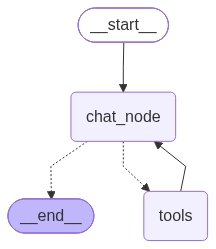

In [38]:
chatbot

13. Invoking the chatbot to generate response

We ask a question --→ LLM receives it --→ LLM may use a PDF/tool --→ tool returns information --→ LLM gives the answer ---→ stored in result

In [41]:
result = chatbot.invoke({
        "messages": [
            HumanMessage(
                content= (
                    "using the pdf notes, explain how to split a node in decision tree"
                )
            )
        ]
})
# chatbot.invoke(...) ---→ runs the entire graph.
# "messages" ---→ provides the conversation input.
# HumanMessage(...) ---→ represents a user message.
# content ---→ is the actual question we are asking.
# result ---→ stores the chatbot's final result.


In [42]:
# returning/ generationg the final results

print(result['messages'][-1].content)

To split a node in a decision tree, you need to find the most informative feature that can best separate the data points in the node. This is done by calculating the information gain for each feature and selecting the one with the highest information gain.

Here are the steps to split a node in a decision tree:

1.  **Calculate the information gain**: For each feature, calculate the information gain by measuring the reduction in impurity (e.g., Gini impurity or entropy) after splitting the data points based on the feature values.
2.  **Select the best feature**: Select the feature with the highest information gain as the next feature to split on.
3.  **Split the data points**: Split the data points in the node based on the selected feature values.
4.  **Create new nodes**: Create new nodes for each subset of data points that fall into the same category (e.g., class label or target value).
5.  **Repeat the process**: Repeat the process for each new node until all data points are in a pu